# Comparaison Heston (1993) / HN (2000) / CHJ (2009) — Analyse des résultats

Trois modèles de pricing d'options par inversion de Fourier de la fonction
caractéristique sont calibrés sur les chaînes d'options AAPL à trois dates
représentant trois régimes de volatilité (calm / normal / stressed). Pour
chaque calibration, on mesure la qualité du fit in-sample et la performance
prédictive à 1 jour et 5 jours.

**Ce notebook lit les parquets pré-calculés par `scripts/run_batch.py`.** Pas
de calibration ici, juste de la lecture, des plots et de l'interprétation.


## 1. Setup — ce qu'on a calibré

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

MODEL_COLORS = {'heston93': '#1f77b4', 'hn2000': '#ff7f0e', 'chj2009': '#2ca02c'}
MODEL_NAMES  = {'heston93': 'Heston 93', 'hn2000': 'HN 00', 'chj2009': 'CHJ 09'}
REGIME_ORDER = ['calm', 'normal', 'stressed']
MODELS = ['heston93', 'hn2000', 'chj2009']

from src.config import load_config
from src.analysis import attach_sector, sectors_present, sector_coverage, tickers_in_sector
cfg = load_config('../config.yaml')
SECTOR_MAP = cfg.sectors
print(f'Secteurs déclarés : {list(SECTOR_MAP)}')

metrics = pd.read_parquet('../results/batch_results.parquet')
metrics['date'] = pd.to_datetime(metrics['date'])
metrics = attach_sector(metrics, SECTOR_MAP)

# Horizons OOS présents dans le parquet (adaptatif)
HORIZONS = sorted(set(
    int(c.split('_J')[1]) for c in metrics.columns
    if c.startswith('oos_iv_vega_rmse_J')
))
print(f'Horizons OOS disponibles : J+{HORIZONS}')

print('\nCouverture sectorielle :')
print(sector_coverage(metrics, SECTOR_MAP).to_string(index=False))

# Tableau récap adaptatif
oos_cols = [f'oos_iv_vega_rmse_J{h}' for h in HORIZONS if f'oos_iv_vega_rmse_J{h}' in metrics.columns]
recap = metrics[['date', 'ticker', 'sector', 'model', 'regime', 'n_options',
                  'in_sample_iv_vega_rmse'] + oos_cols + ['calibration_time_sec']].copy()
recap['date'] = recap['date'].dt.date
recap.round(3)

Secteurs déclarés : ['Tech', 'Consumer', 'Financials', 'Energy', 'Healthcare']
Horizons OOS disponibles : J+[1, 3, 7, 15]

Couverture sectorielle :
    sector  n_declared  n_calibrated          tickers
      Tech           3             3 AAPL, MSFT, NVDA
  Consumer           2             2         AMZN, PG
Financials           2             2          GS, JPM
    Energy           2             2         CVX, XOM
Healthcare           1             1              UNH


,date,ticker,sector,model,regime,n_options,in_sample_iv_vega_rmse,oos_iv_vega_rmse_J1,oos_iv_vega_rmse_J3,oos_iv_vega_rmse_J7,oos_iv_vega_rmse_J15,calibration_time_sec
0,2024-06-03,AAPL,Tech,heston93,calm,252,0.761,0.784,0.760,0.890,0.982,29.971
1,2024-06-03,AAPL,Tech,hn2000,calm,252,0.770,0.792,0.766,1.066,1.006,219.335
2,2024-06-03,AAPL,Tech,chj2009,calm,252,0.712,0.729,0.719,0.839,1.356,194.372
3,2024-06-03,MSFT,Tech,heston93,calm,371,1.625,1.669,1.749,1.838,2.318,34.334
4,2024-06-03,MSFT,Tech,hn2000,calm,371,1.704,1.695,1.852,2.084,2.631,111.415
...,...,...,...,...,...,...,...,...,...,...,...,...
175,2025-04-02,PG,Consumer,hn2000,stressed,47,0.415,0.817,1.857,1.763,1.176,168.351
176,2025-04-02,PG,Consumer,chj2009,stressed,47,0.413,0.678,2.049,1.475,1.292,143.250
177,2025-04-02,UNH,Healthcare,heston93,stressed,177,1.814,2.617,7.105,2.425,3.292,16.500
178,2025-04-02,UNH,Healthcare,hn2000,stressed,177,1.849,2.994,7.983,4.153,3.311,105.711


### Contexte volatilité — justification des régimes

Vol réalisée 21j moyenne des 6 tickers (proxy de la VIX). Les bandes
verticales matérialisent les 3 mois de test choisis dans `config.yaml`.

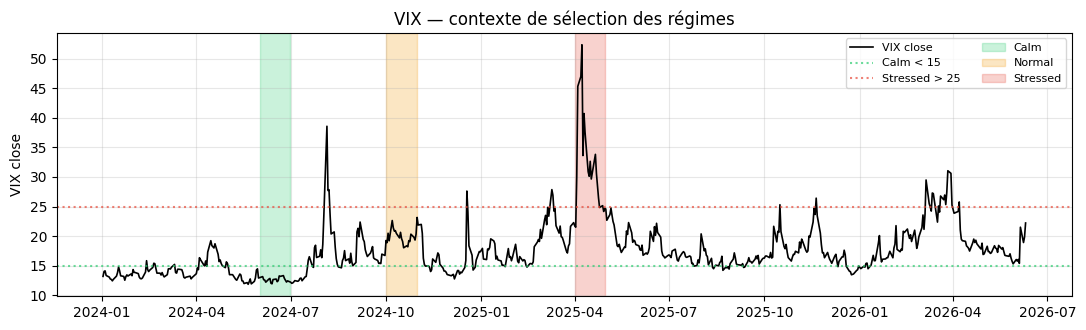

VIX moyen dans chaque mois de test :
  calm       2024-06-01 -> 2024-06-30: VIX moy = 12.7  -> calm
  normal     2024-10-01 -> 2024-10-31: VIX moy = 20.0  -> normal
  stressed   2025-04-01 -> 2025-04-30: VIX moy = 32.0  -> stressed


In [2]:
vix_path = cfg.vix_file
if vix_path is None or not vix_path.exists():
    raise FileNotFoundError('VIX file not configured or not found — set `vix_file` in config.yaml')

vix = pd.read_parquet(vix_path, columns=['created', 'close']).rename(
    columns={'created': 'date', 'close': 'vix'})
vix['date'] = pd.to_datetime(vix['date']).dt.tz_localize(None).dt.normalize()
vix = vix.sort_values('date').reset_index(drop=True)

REGIME_COLORS = {'calm': '#2ecc71', 'normal': '#f39c12', 'stressed': '#e74c3c'}
CALM_THRESHOLD = 15.0
STRESS_THRESHOLD = 25.0

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(vix.date, vix.vix, color='black', linewidth=1.2, label='VIX close')

# Seuils horizontaux pour la classification
ax.axhline(CALM_THRESHOLD, color=REGIME_COLORS['calm'], linestyle=':', alpha=0.7,
           label=f'Calm < {CALM_THRESHOLD:.0f}')
ax.axhline(STRESS_THRESHOLD, color=REGIME_COLORS['stressed'], linestyle=':', alpha=0.7,
           label=f'Stressed > {STRESS_THRESHOLD:.0f}')

# Bandes verticales pour les mois de test
labels_done = set()
for regime, dates_list in cfg.oos['test_months'].items():
    for d in dates_list:
        d = pd.Timestamp(d)
        end = d + pd.offsets.MonthEnd(0)
        lbl = regime.capitalize() if regime not in labels_done else None
        ax.axvspan(d, end, alpha=0.25, color=REGIME_COLORS.get(regime, 'gray'),
                   label=lbl)
        labels_done.add(regime)

ax.set_ylabel('VIX close')
ax.set_title('VIX — contexte de sélection des régimes')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../results/figures/00_vol_context.png', dpi=120, bbox_inches='tight')
plt.show()

# Diagnostic : VIX moyen pendant chacun des mois de test
print('VIX moyen dans chaque mois de test :')
for regime, dates_list in cfg.oos['test_months'].items():
    for d in dates_list:
        d = pd.Timestamp(d)
        end = d + pd.offsets.MonthEnd(0)
        m_vix = vix[(vix.date >= d) & (vix.date <= end)].vix.mean()
        cls = 'calm' if m_vix < CALM_THRESHOLD else ('stressed' if m_vix > STRESS_THRESHOLD else 'normal')
        ok = '' if cls == regime else f'  != label "{regime}"'
        print(f'  {regime:10s} {d.date()} -> {end.date()}: VIX moy = {m_vix:.1f}  -> {cls}{ok}')

## 2. Comparaison globale in-sample

**Question.** À chaque date de calibration, quel modèle minimise le mieux la
loss IV-vega RMSE sur le panel d'options ?

**Lecture.** Plus la barre est basse, mieux le modèle fitte. On compare les
3 modèles côte à côte dans chaque régime de volatilité.


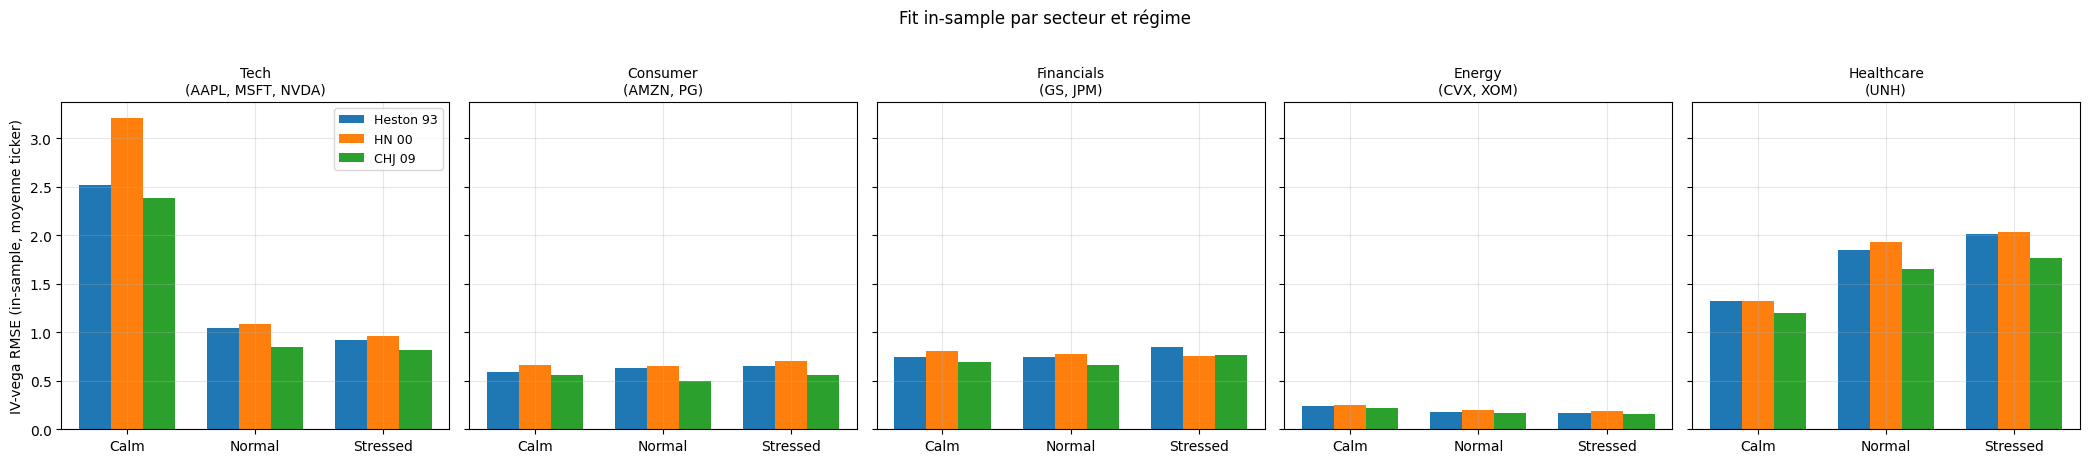

In [3]:
# Vue par SECTEUR : pour chaque secteur, moyenne du loss sur ses tickers
sectors = sectors_present(metrics, SECTOR_MAP)
n_sec = len(sectors)
fig, axes = plt.subplots(1, n_sec, figsize=(4.2 * n_sec, 4.5), sharey=True)
axes = np.atleast_1d(axes)

x = np.arange(len(REGIME_ORDER))
w = 0.25

for ax, sec in zip(axes, sectors):
    sub = metrics[metrics.sector == sec]
    tickers_sec = sorted(sub.ticker.unique())
    for i, m in enumerate(MODELS):
        vals = [
            sub[(sub.regime == r) & (sub.model == m)]['in_sample_iv_vega_rmse'].mean()
            for r in REGIME_ORDER
        ]
        ax.bar(x + (i - 1) * w, vals, w, label=MODEL_NAMES[m], color=MODEL_COLORS[m])
    ax.set_xticks(x)
    ax.set_xticklabels([r.capitalize() for r in REGIME_ORDER])
    ax.set_title(f'{sec}\n({", ".join(tickers_sec)})', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('IV-vega RMSE (in-sample, moyenne ticker)')
        ax.legend(fontsize=9)

fig.suptitle('Fit in-sample par secteur et régime', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/01_in_sample_by_sector.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Fit du smile de volatilité

**Question.** Pour chaque date, à quoi ressemble le smile observé sur le
marché et comment chaque modèle le reproduit ?

**Lecture.** Les points noirs = IV implicite du marché (chaque option = 1 point).
Les courbes en couleur = IV implicite prédite par chaque modèle calibré.
Plus la courbe colle aux points, mieux le modèle capture la forme du smile.

C'est le test visuel le plus parlant — il montre où chaque modèle pèche
(short maturity, deep OTM, etc.).


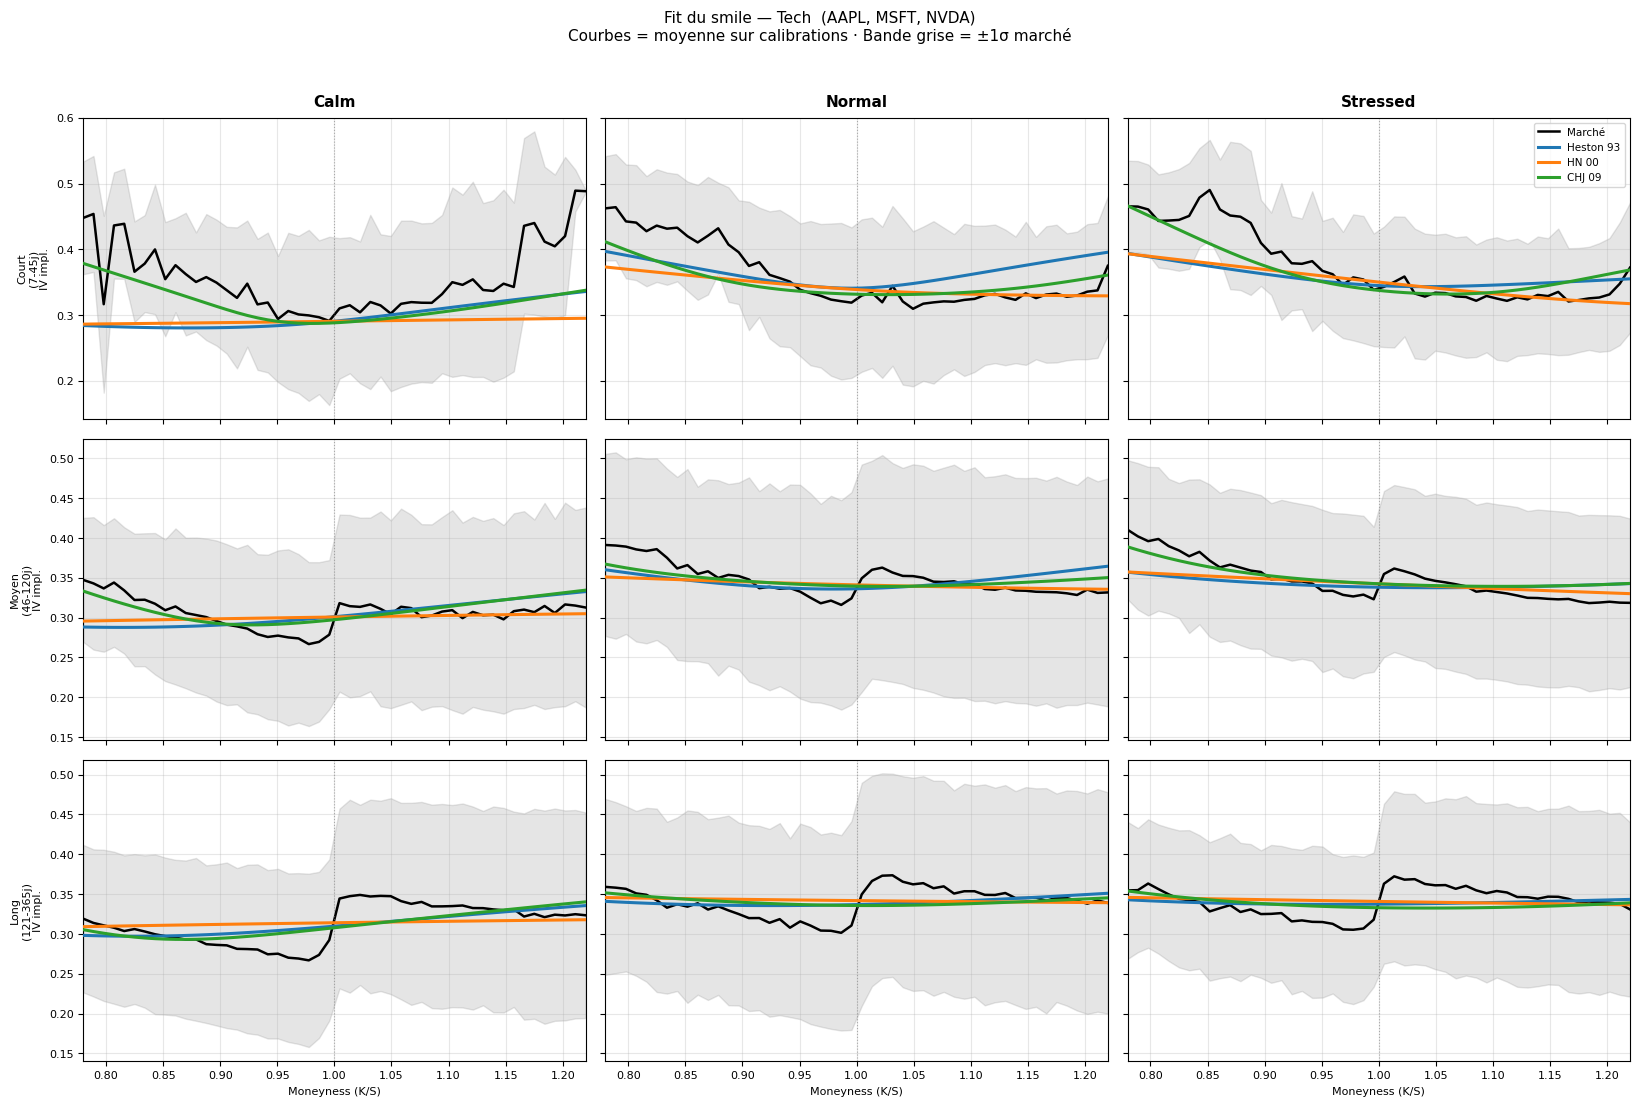

Saved: ../results/figures/02_smile_tech.png


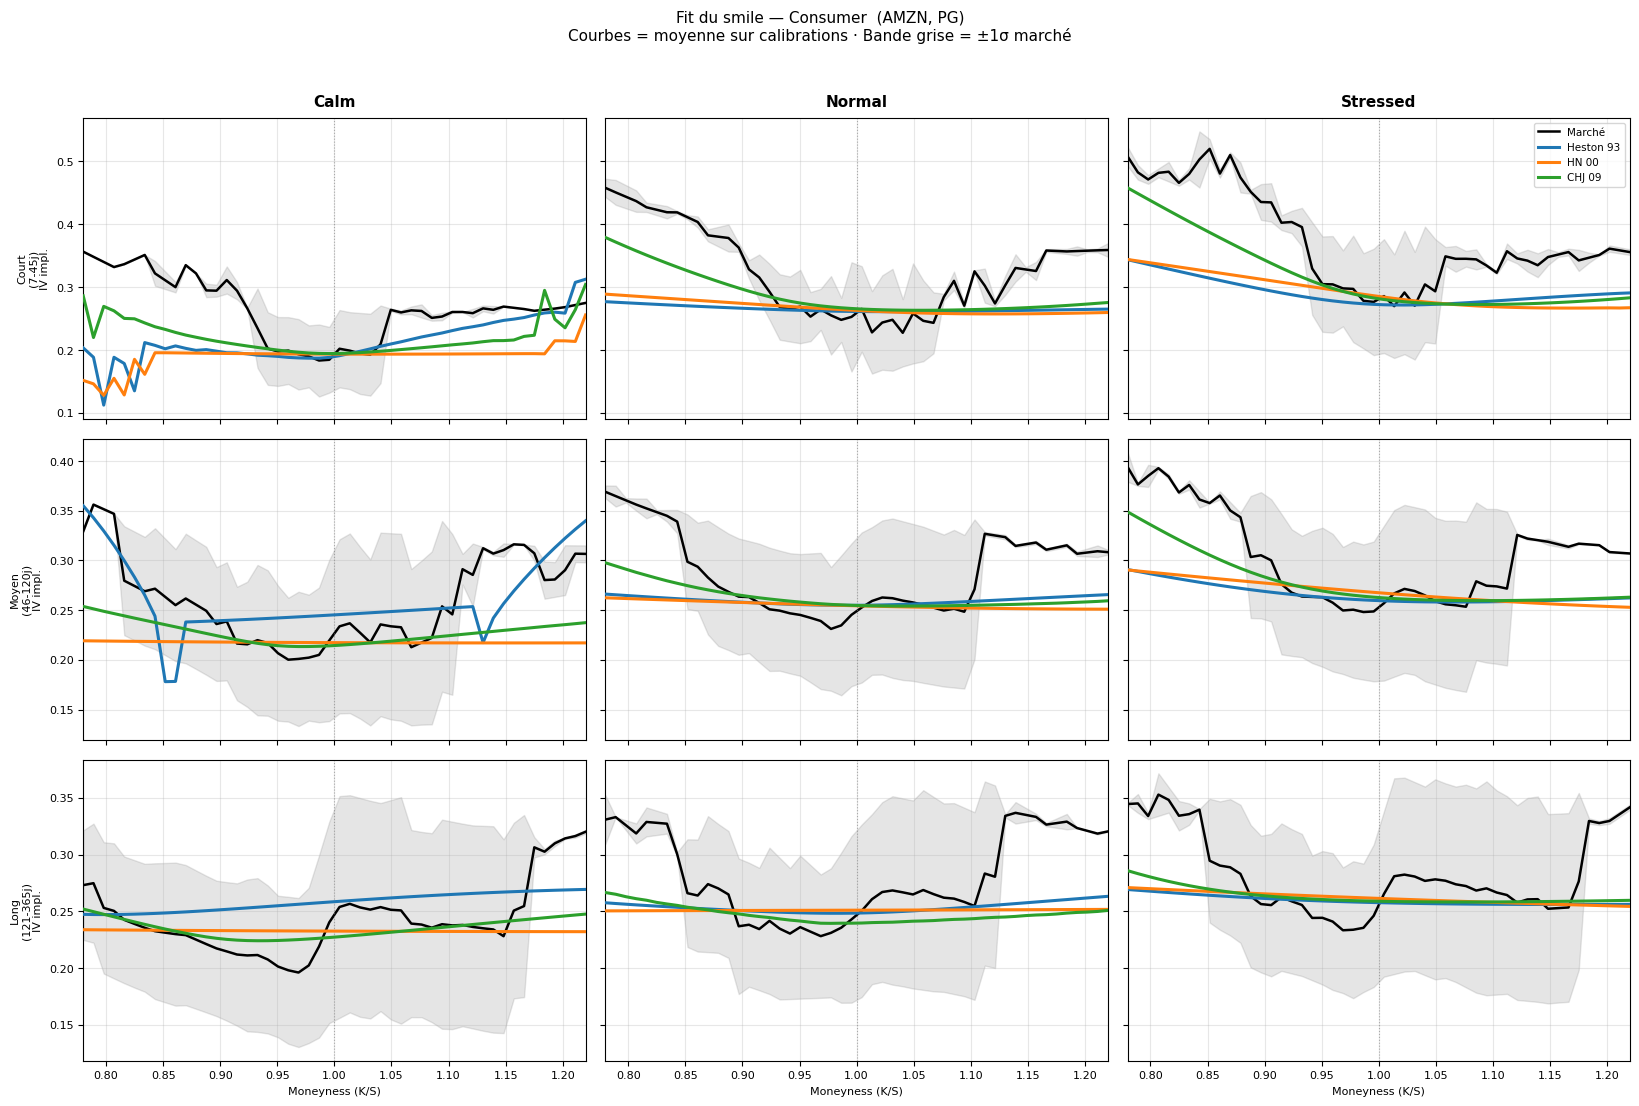

Saved: ../results/figures/02_smile_consumer.png


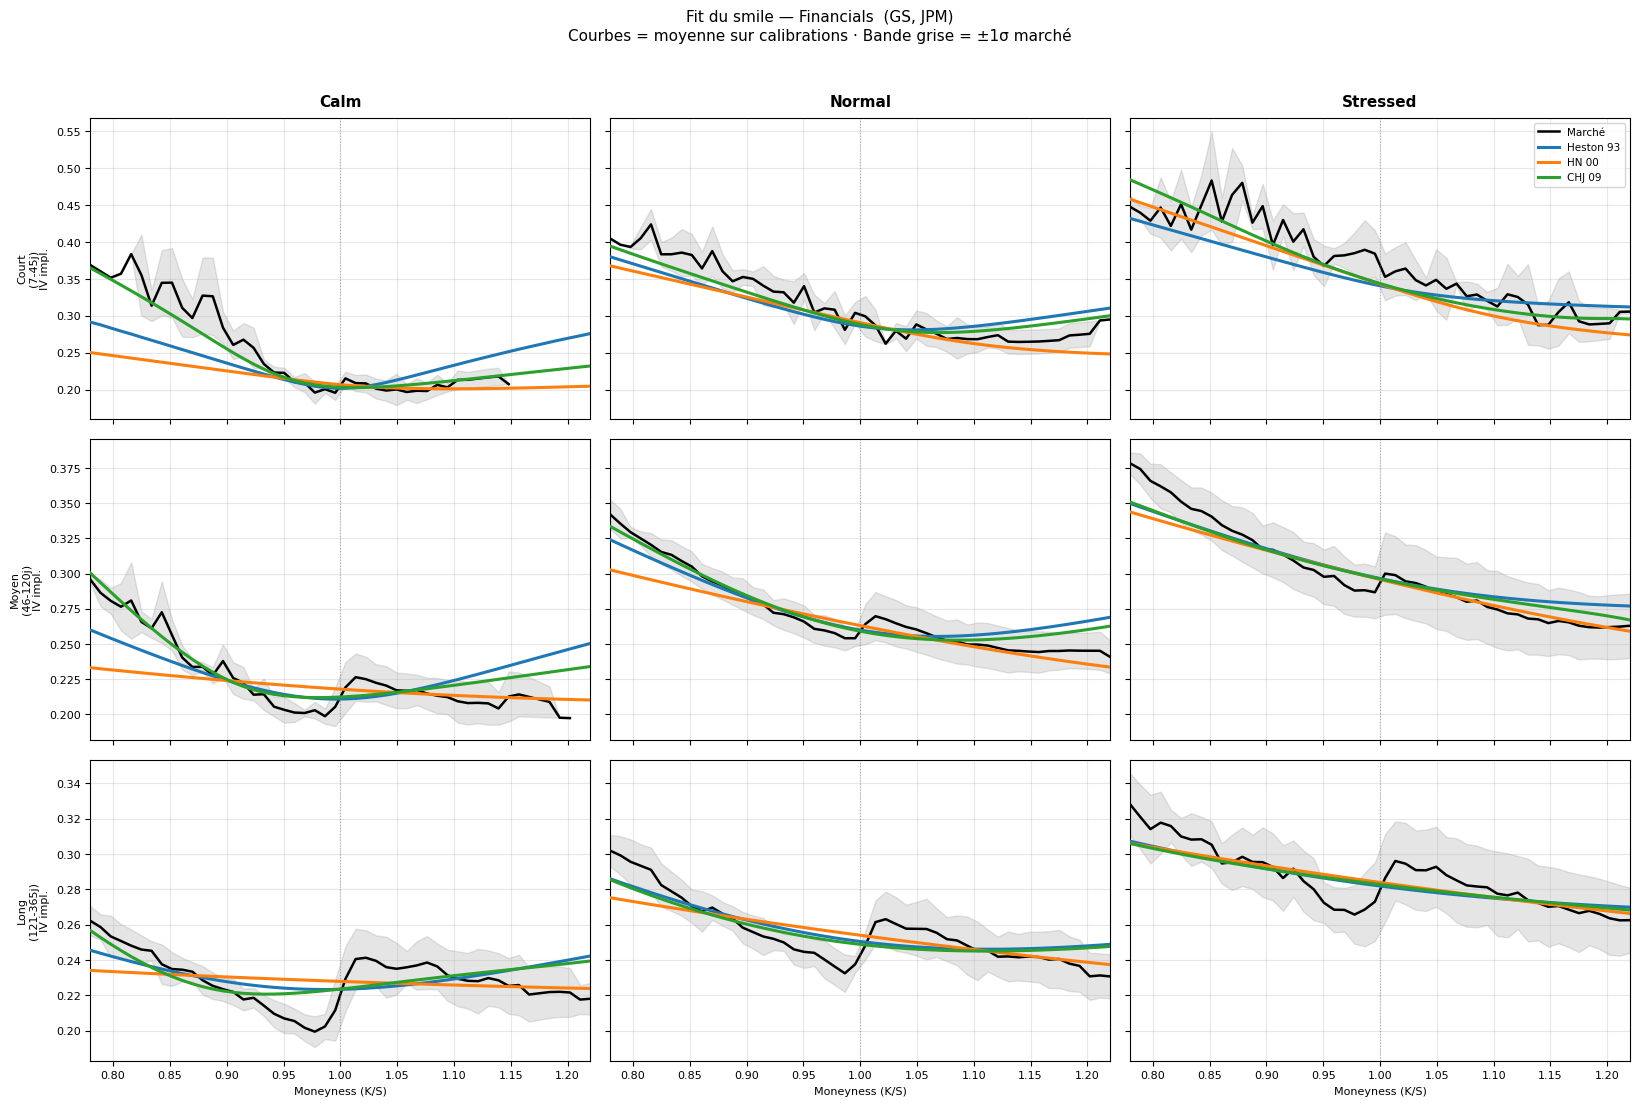

Saved: ../results/figures/02_smile_financials.png


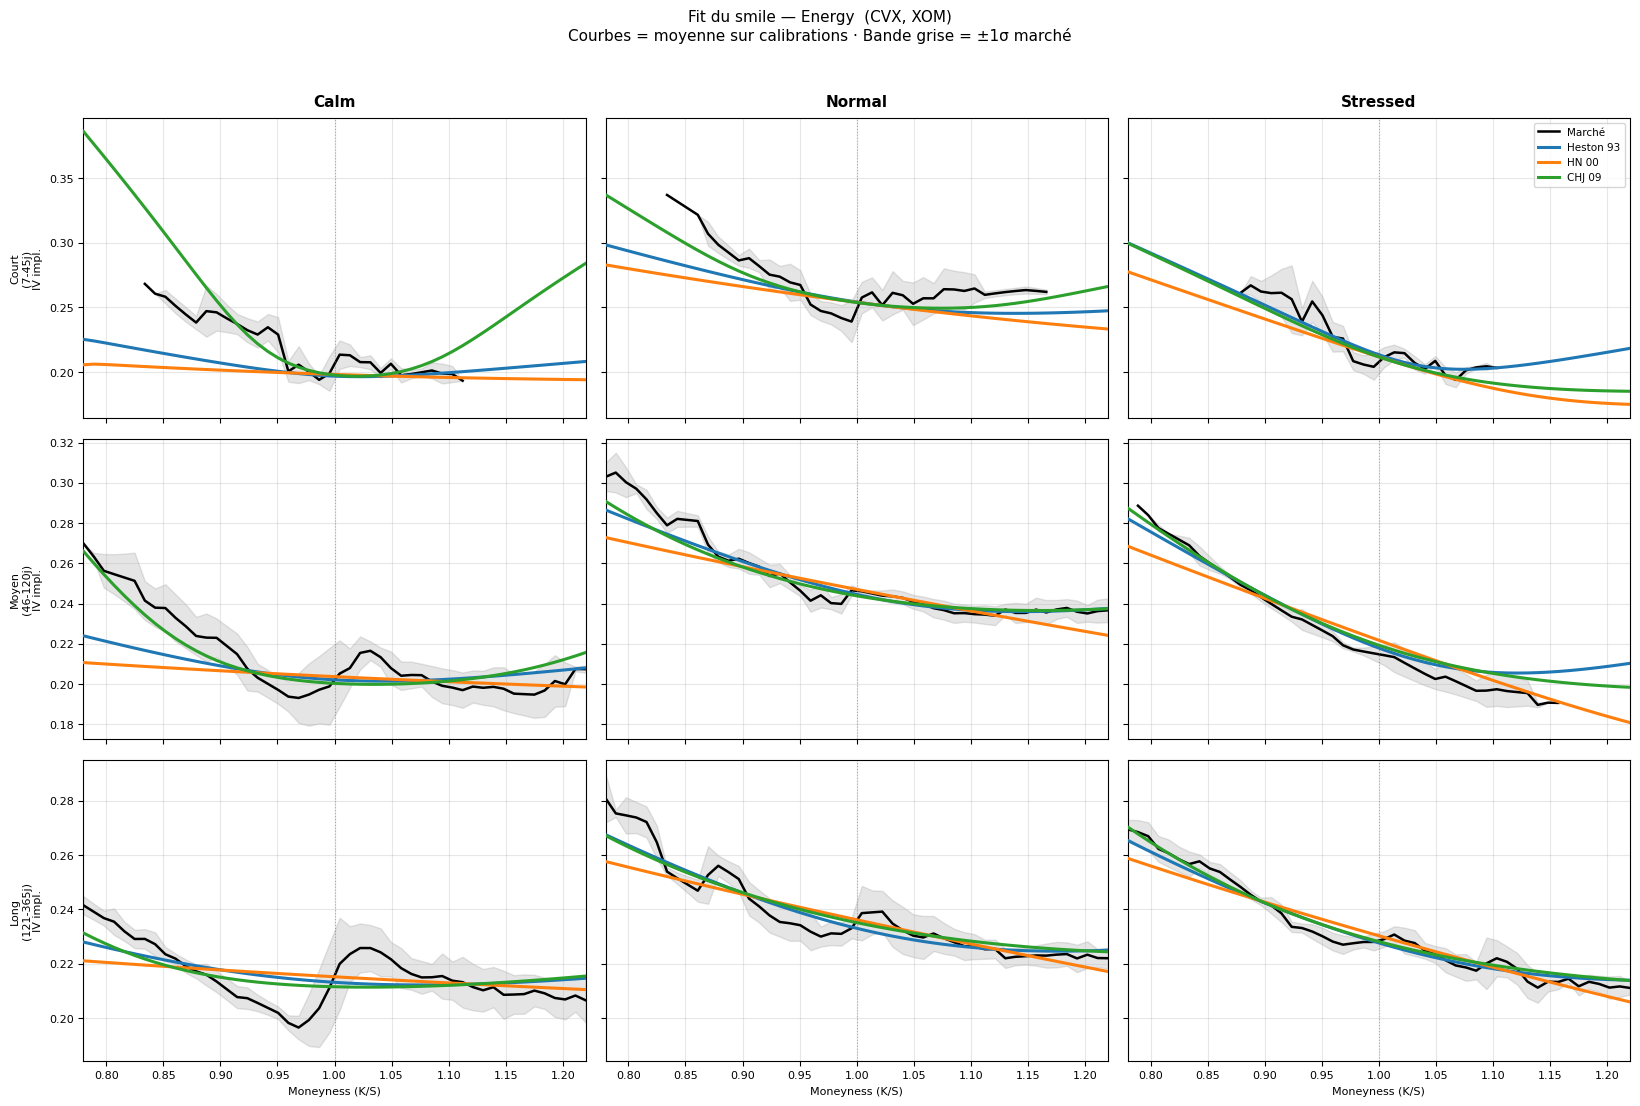

Saved: ../results/figures/02_smile_energy.png


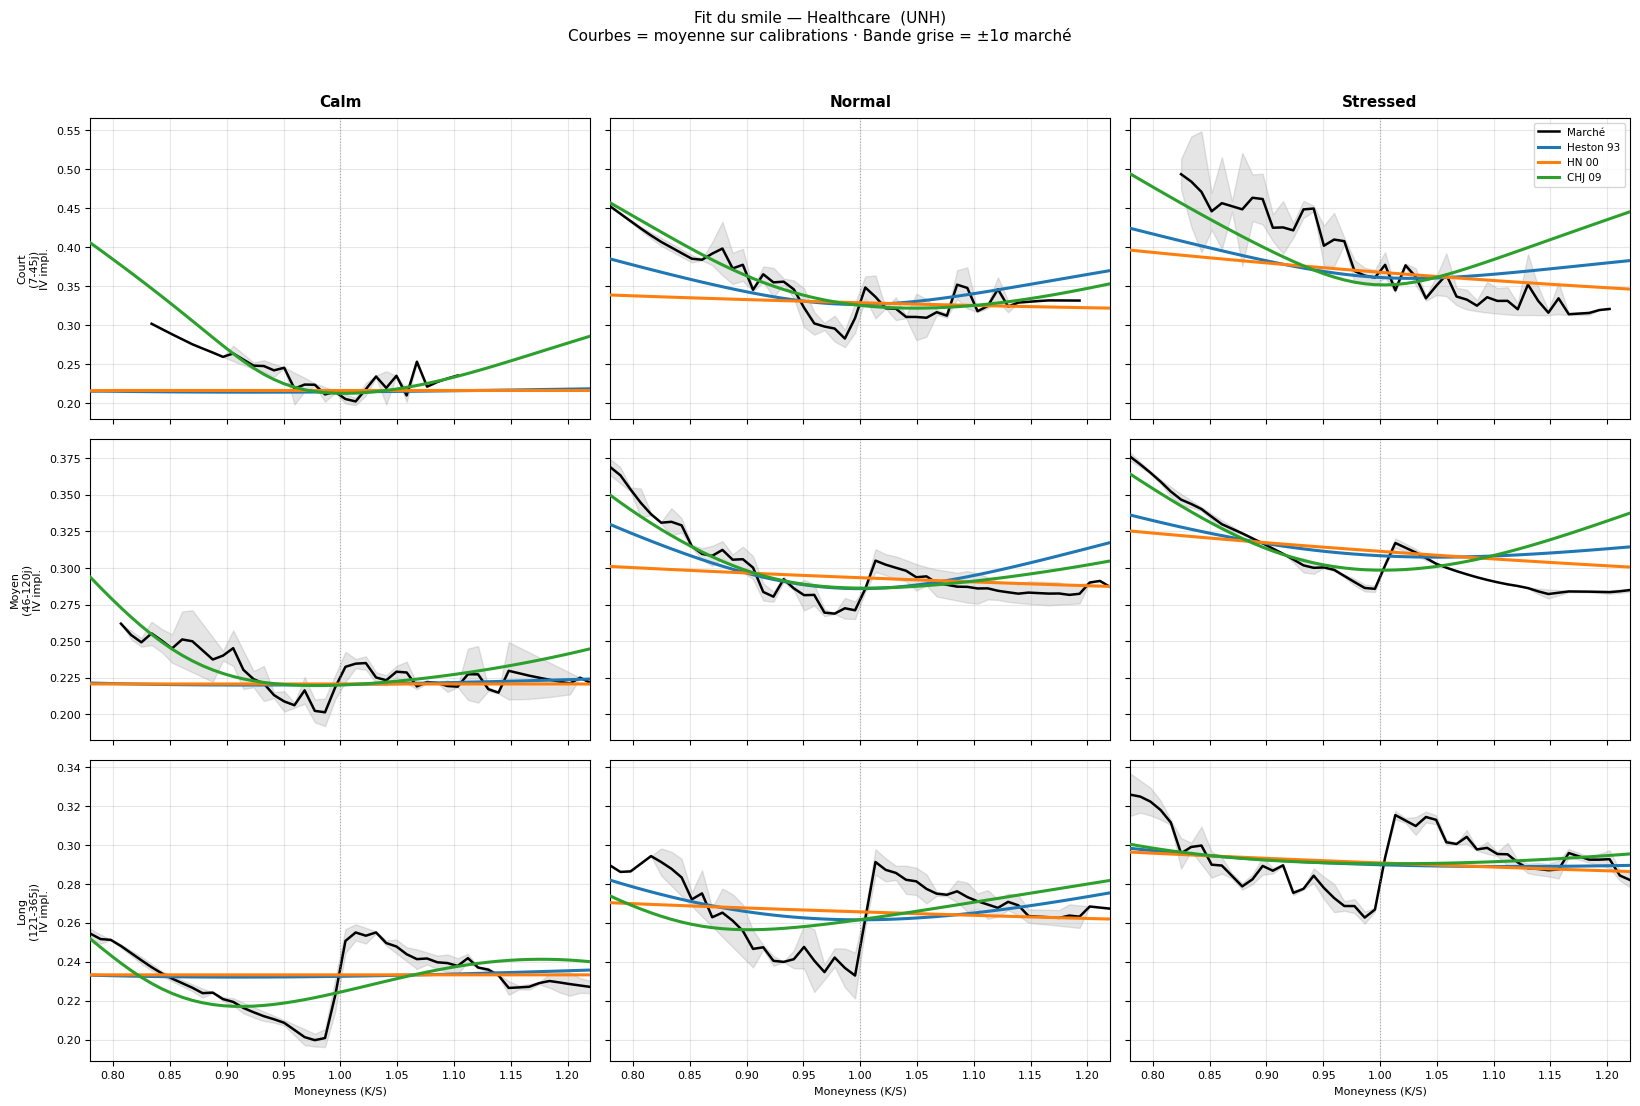

Saved: ../results/figures/02_smile_healthcare.png


In [4]:
from src.preprocessing import load_chain, FilterConfig, filter_chain, add_implied_vol
from src.models import MODEL_REGISTRY, implied_vol_vec
from matplotlib.lines import Line2D

filt_cfg    = FilterConfig(**cfg.filters, r_annual=cfg.calibration['r_annual'])
params_long = pd.read_parquet('../results/params_long.parquet')
params_long['date'] = pd.to_datetime(params_long['date'])

sectors = sectors_present(metrics, SECTOR_MAP)
regimes = [r for r in ['calm', 'normal', 'stressed'] if r in metrics.regime.values]

DTE_BUCKETS = [
    ('Court\n(7-45j)',    7,   45),
    ('Moyen\n(46-120j)', 46,  120),
    ('Long\n(121-365j)', 121, 365),
]
MON_GRID = np.linspace(0.78, 1.22, 50)
R_F = cfg.calibration['r_annual']


def _market_iv_on_grid(d, ticker, dte_lo, dte_hi):
    try:
        chain = load_chain(d, ticker, cfg.data_root)
    except Exception:
        return None
    clean = filter_chain(chain, filt_cfg)
    clean = add_implied_vol(clean, R_F)
    sm = clean[(clean.dte >= dte_lo) & (clean.dte <= dte_hi) & (clean.iv > 0.05)]
    if len(sm) < 4:
        return None
    sm = sm.sort_values('moneyness')
    return np.interp(MON_GRID, sm.moneyness.values, sm.iv.values,
                     left=np.nan, right=np.nan)


def _model_iv_on_grid(d, ticker, dte_lo, dte_hi, model_name):
    try:
        chain = load_chain(d, ticker, cfg.data_root)
    except Exception:
        return None
    clean = filter_chain(chain, filt_cfg)
    clean = add_implied_vol(clean, R_F)
    sm = clean[(clean.dte >= dte_lo) & (clean.dte <= dte_hi) & (clean.iv > 0.05)]
    if len(sm) < 4:
        return None
    sub = params_long[(params_long.date == d) & (params_long.ticker == ticker)
                      & (params_long.model == model_name)]
    if sub.empty:
        return None
    pricer = MODEL_REGISTRY[model_name].from_calibration_vector(
        sub['param_value'].to_numpy(), r_f=R_F)
    spot    = sm.spot.mean()
    T       = sm.dte.mean() / 365
    strikes = MON_GRID * spot
    # price_chain(S, K, T, rights) — r_f is stored in pricer, not a parameter
    prices = pricer.price_chain(
        np.full(len(MON_GRID), spot),
        strikes,
        np.full(len(MON_GRID), T),
        np.array(['C'] * len(MON_GRID)),
    )
    return implied_vol_vec(prices,
                           np.full(len(MON_GRID), spot), strikes,
                           np.full(len(MON_GRID), T), R_F,
                           np.array(['C'] * len(MON_GRID)))


# ── une figure par secteur ────────────────────────────────────────────────────
for sec in sectors:
    tickers_sec = tickers_in_sector(sec, metrics, SECTOR_MAP)
    n_reg = len(regimes)
    n_bkt = len(DTE_BUCKETS)

    fig, axes = plt.subplots(n_bkt, n_reg,
                             figsize=(5.5 * n_reg, 3.6 * n_bkt),
                             sharex=True, sharey='row')
    axes = np.array(axes).reshape(n_bkt, n_reg)

    for j, regime in enumerate(regimes):
        dates_reg = sorted(metrics[(metrics.sector == sec) & (metrics.regime == regime)]
                           .date.unique())

        for i, (bkt_label, dte_lo, dte_hi) in enumerate(DTE_BUCKETS):
            ax = axes[i, j]

            # Marché : bande grise = moy ± std
            mkt_curves = []
            for d in dates_reg:
                for t in tickers_sec:
                    iv = _market_iv_on_grid(d, t, dte_lo, dte_hi)
                    if iv is not None:
                        mkt_curves.append(iv)

            if mkt_curves:
                mkt = np.array(mkt_curves)
                mu  = np.nanmean(mkt, axis=0)
                sig = np.nanstd(mkt,  axis=0)
                ax.fill_between(MON_GRID, mu - sig, mu + sig,
                                color='#555555', alpha=0.15, zorder=1)
                ax.plot(MON_GRID, mu, color='black', lw=1.8, label='Marché', zorder=2)

            # Modèles : courbe moyenne
            for m in MODELS:
                mod_curves = []
                for d in dates_reg:
                    for t in tickers_sec:
                        iv = _model_iv_on_grid(d, t, dte_lo, dte_hi, m)
                        if iv is not None:
                            mod_curves.append(iv)
                if not mod_curves:
                    continue
                mean_iv = np.nanmean(np.array(mod_curves), axis=0)
                ax.plot(MON_GRID, mean_iv, lw=2.2,
                        color=MODEL_COLORS[m], label=MODEL_NAMES[m], zorder=3)

            ax.axvline(1.0, color='gray', ls=':', lw=0.8, alpha=0.6)
            ax.set_xlim(MON_GRID[0], MON_GRID[-1])
            ax.tick_params(labelsize=8)
            if i == 0:
                ax.set_title(regime.capitalize(), fontsize=11, fontweight='bold', pad=8)
            if j == 0:
                ax.set_ylabel(f'{bkt_label}\nIV impl.', fontsize=8)
            if i == n_bkt - 1:
                ax.set_xlabel('Moneyness (K/S)', fontsize=8)
            if i == 0 and j == n_reg - 1:
                ax.legend(fontsize=7.5, loc='upper right')

    fig.suptitle(f'Fit du smile — {sec}  ({", ".join(tickers_sec)})\n'
                 f'Courbes = moyenne sur calibrations · Bande grise = ±1σ marché',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    fname = f'../results/figures/02_smile_{sec.lower()}.png'
    plt.savefig(fname, dpi=140, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

## 4. Performance prédictive : courbe de dégradation in-sample → J+N

**Question.** Comment la qualité du pricing se dégrade-t-elle à mesure qu'on s'éloigne
du jour de calibration ?

**Lecture.** X = horizon en jours de bourse depuis la calibration (0 = in-sample).
Y = IV-vega RMSE moyen. Une courbe plate = paramètres stables dans le temps.
Une courbe qui monte vite = surfit (les paramètres collent à la date de calibration
mais ne généralisent pas). Comparer les pentes entre modèles est le cœur du test OOS.

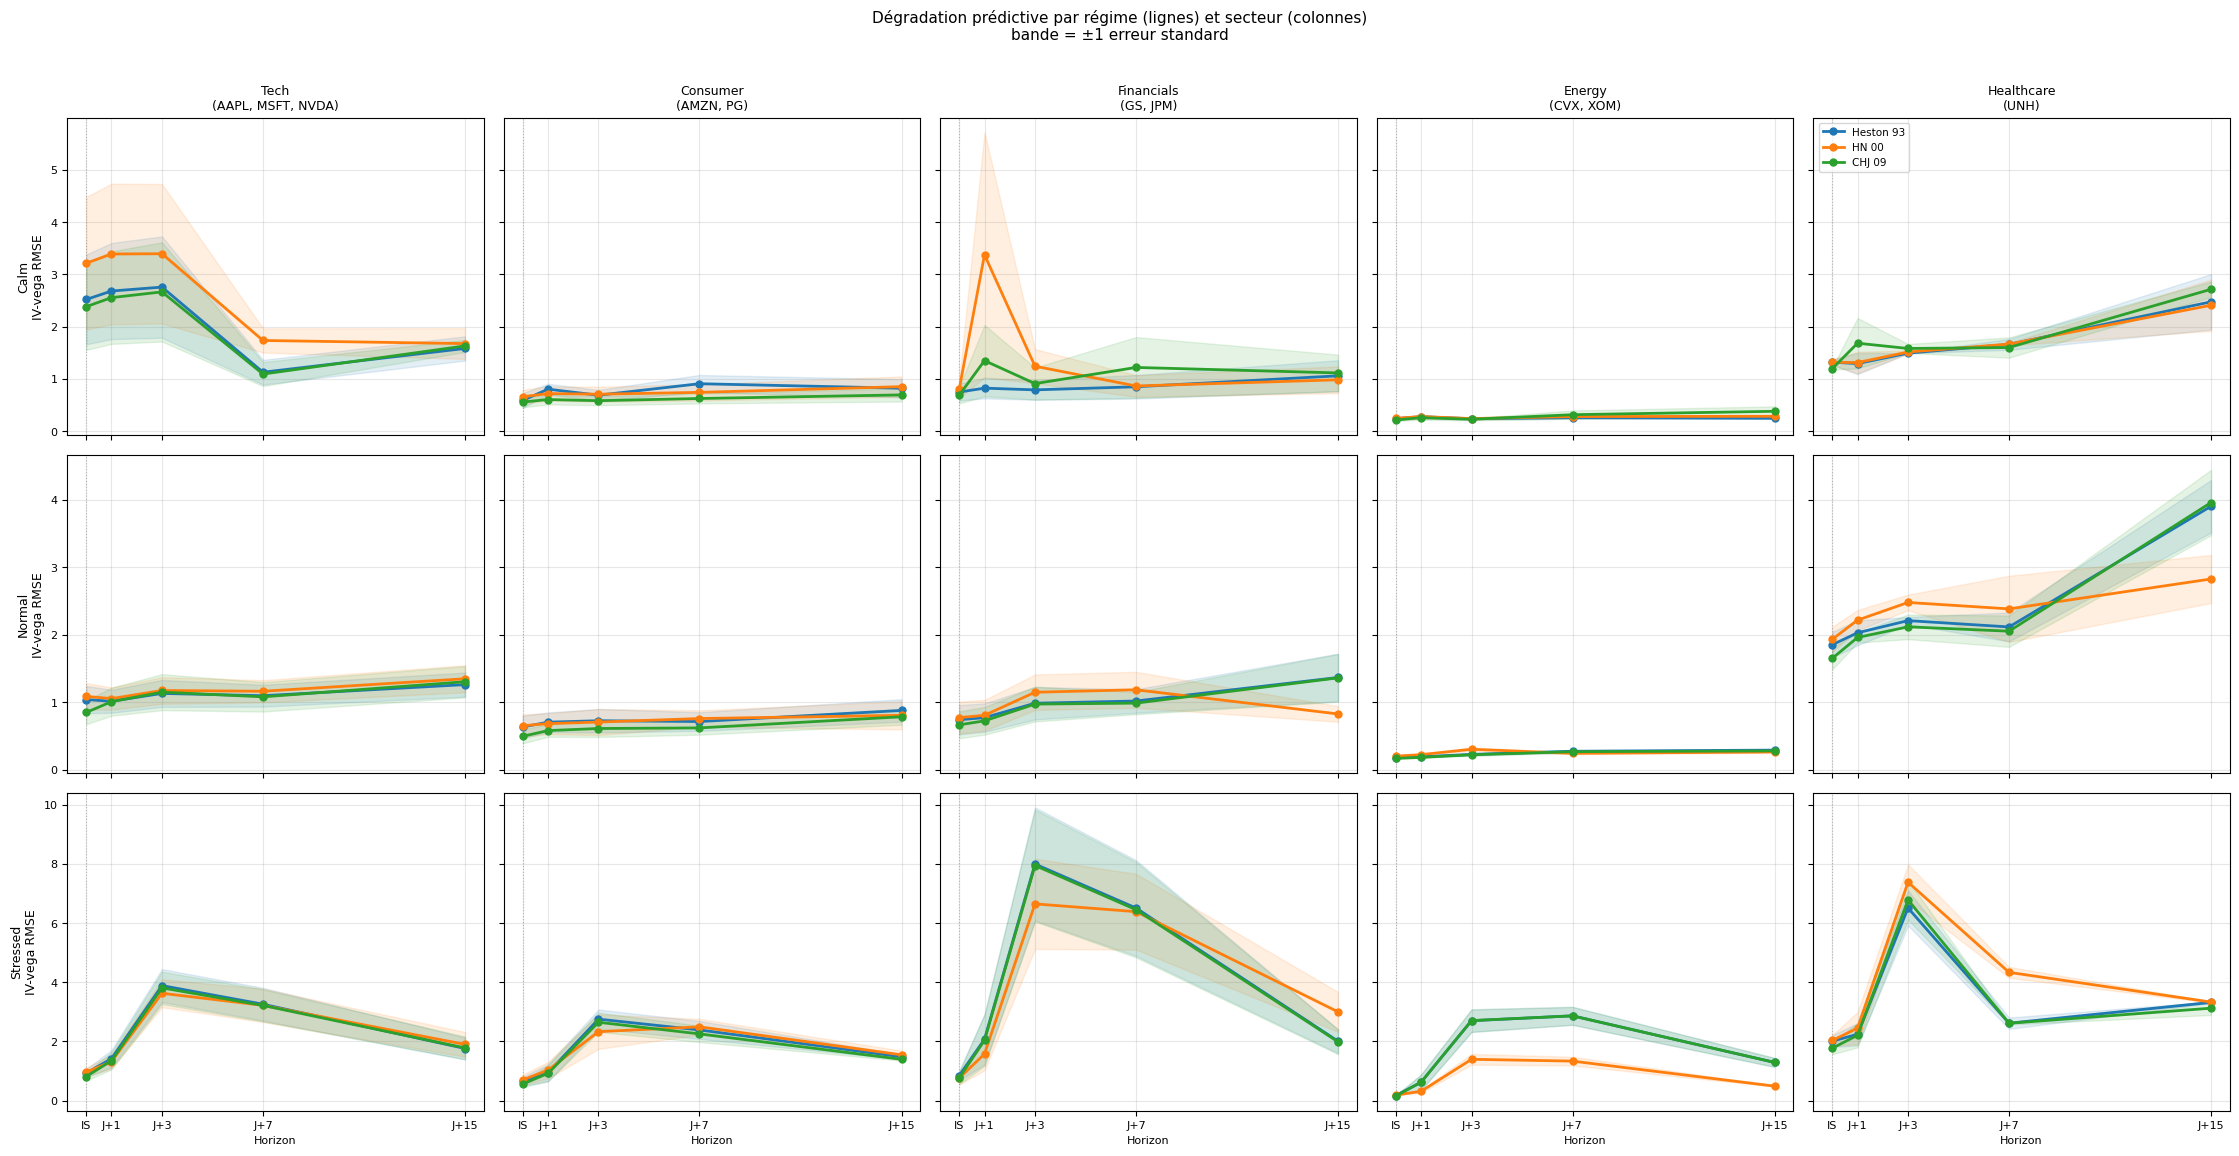

IS    J+1    J+3    J+7   J+15    Gap
regime   sector     model                                              
calm     Tech       Heston 93  2.521  2.683  2.758  1.130  1.585 -0.937
         Consumer   Heston 93  0.590  0.806  0.690  0.910  0.824  0.235
         Financials Heston 93  0.750  0.825  0.792  0.851  1.061  0.311
         Energy     Heston 93  0.241  0.279  0.240  0.261  0.248  0.006
         Healthcare Heston 93  1.322  1.295  1.495  1.663  2.477  1.155
         Tech       HN 00      3.215  3.391  3.396  1.737  1.677 -1.538
         Consumer   HN 00      0.661  0.722  0.709  0.744  0.854  0.193
         Financials HN 00      0.809  3.376  1.244  0.867  0.985  0.176
         Energy     HN 00      0.248  0.280  0.243  0.282  0.287  0.039
         Healthcare HN 00      1.320  1.315  1.517  1.668  2.411  1.091
         Tech       CHJ 09     2.384  2.557  2.666  1.094  1.633 -0.751
         Consumer   CHJ 09     0.560  0.607  0.585  0.627  0.696  0.136
         Financials CHJ 09     0.692  1.351  0.912  1.221  1.116  0.424
         Energy     CHJ 09     0.216  0.260  0.230  0.317  0.382  0.167
         Healthcare CHJ 09     1.198  1.685  1.584  1.603  2.716  1.519
normal   Tech       Heston 93  1.040  1.015  1.131  1.098  1.262  0.221
         Consumer   Heston 93  0.634  0.705  0.727  0.715  0.879  0.245
         Financials Heston 93  0.742  0.773  0.986  1.019  1.368  0.626
         Energy     Heston 93  0.181  0.194  0.228  0.275  0.292  0.111
         Healthcare Heston 93  1.853  2.029  2.209  2.116  3.903  2.050
         Tech       HN 00      1.087  1.055  1.175  1.163  1.348  0.261
         Consumer   HN 00      0.653  0.684  0.707  0.759  0.807  0.154
         Financials HN 00      0.773  0.807  1.149  1.185  0.827  0.054
         Energy     HN 00      0.202  0.225  0.304  0.244  0.264  0.062
         Healthcare HN 00      1.933  2.217  2.479  2.383  2.826  0.893
         Tech       CHJ 09     0.849  1.009  1.150  1.081  1.304  0.455
         Consumer   CHJ 09     0.496  0.581  0.612  0.621  0.785  0.289
         Financials CHJ 09     0.666  0.725  0.973  0.987  1.362  0.696
         Energy     CHJ 09     0.169  0.184  0.223  0.268  0.280  0.111
         Healthcare CHJ 09     1.652  1.960  2.117  2.053  3.959  2.307
stressed Tech       Heston 93  0.925  1.418  3.889  3.259  1.761  0.836
         Consumer   Heston 93  0.652  0.943  2.755  2.388  1.482  0.829
         Financials Heston 93  0.845  2.073  8.001  6.512  2.009  1.163
         Energy     Heston 93  0.170  0.619  2.701  2.867  1.291  1.121
         Healthcare Heston 93  2.011  2.241  6.514  2.617  3.321  1.310
         Tech       HN 00      0.961  1.318  3.629  3.220  1.901  0.940
         Consumer   HN 00      0.703  1.029  2.331  2.495  1.547  0.844
         Financials HN 00      0.761  1.577  6.652  6.388  3.001  2.240
         Energy     HN 00      0.190  0.312  1.396  1.335  0.489  0.299
         Healthcare HN 00      2.032  2.451  7.384  4.337  3.331  1.299
         Tech       CHJ 09     0.814  1.347  3.811  3.218  1.781  0.967
         Consumer   CHJ 09     0.557  0.920  2.648  2.256  1.395  0.838
         Financials CHJ 09     0.765  2.040  7.950  6.455  1.986  1.221
         Energy     CHJ 09     0.156  0.619  2.706  2.865  1.291  1.135
         Healthcare CHJ 09     1.772  2.208  6.785  2.615  3.125  1.353

In [5]:
sectors = sectors_present(metrics, SECTOR_MAP)
regimes = [r for r in REGIME_ORDER if r in metrics.regime.values]
n_sec = len(sectors)
n_reg = len(regimes)

x_pts    = [0] + HORIZONS
x_labels = ['IS'] + [f'J+{h}' for h in HORIZONS]

fig, axes = plt.subplots(n_reg, n_sec,
                         figsize=(4.5 * n_sec, 3.8 * n_reg),
                         sharey='row', sharex=True)
axes = np.array(axes).reshape(n_reg, n_sec)

for i, regime in enumerate(regimes):
    for j, sec in enumerate(sectors):
        ax = axes[i, j]
        sub = metrics[(metrics.sector == sec) & (metrics.regime == regime)]
        tickers_sec = sorted(sub.ticker.unique())

        for m in MODELS:
            msub = sub[sub.model == m]
            if msub.empty:
                continue
            y_vals = [msub['in_sample_iv_vega_rmse'].mean()]
            y_err  = [msub['in_sample_iv_vega_rmse'].sem()]
            for h in HORIZONS:
                col = f'oos_iv_vega_rmse_J{h}'
                if col in msub.columns and msub[col].notna().any():
                    y_vals.append(msub[col].mean())
                    y_err.append(msub[col].sem())
                else:
                    y_vals.append(np.nan)
                    y_err.append(np.nan)

            y_vals = np.array(y_vals, dtype=float)
            y_err  = np.array(y_err,  dtype=float)
            color  = MODEL_COLORS[m]
            ax.plot(x_pts, y_vals, '-o', color=color, lw=2, ms=5,
                    label=MODEL_NAMES[m], zorder=3)
            ax.fill_between(x_pts, y_vals - y_err, y_vals + y_err,
                            color=color, alpha=0.12, zorder=2)

        ax.axvline(0, color='gray', ls=':', lw=0.8, alpha=0.5)
        ax.set_xticks(x_pts)
        ax.tick_params(labelsize=8)

        if i == 0:
            ax.set_title(f'{sec}\n({", ".join(tickers_sec)})', fontsize=9)
        if j == 0:
            ax.set_ylabel(f'{regime.capitalize()}\nIV-vega RMSE', fontsize=9)
        if i == n_reg - 1:
            ax.set_xticklabels(x_labels, fontsize=8)
            ax.set_xlabel('Horizon', fontsize=8)
        if i == 0 and j == n_sec - 1:
            ax.legend(fontsize=7.5, loc='upper left')

fig.suptitle('Dégradation prédictive par régime (lignes) et secteur (colonnes)\n'
             'bande = ±1 erreur standard',
             y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig('../results/figures/03_predictive_by_sector.png', dpi=130, bbox_inches='tight')
plt.show()

# Tableau synthèse
rows = []
for regime in regimes:
    for m in MODELS:
        for sec in sectors:
            msub = metrics[(metrics.model == m) & (metrics.sector == sec) & (metrics.regime == regime)]
            if msub.empty: continue
            row = {'regime': regime, 'model': MODEL_NAMES[m], 'sector': sec,
                   'IS': round(msub['in_sample_iv_vega_rmse'].mean(), 3)}
            for h in HORIZONS:
                col = f'oos_iv_vega_rmse_J{h}'
                if col in msub.columns:
                    row[f'J+{h}'] = round(msub[col].mean(), 3)
            last_col = f'oos_iv_vega_rmse_J{HORIZONS[-1]}'
            if last_col in msub.columns:
                row['Gap'] = round(msub[last_col].mean() - msub['in_sample_iv_vega_rmse'].mean(), 3)
            rows.append(row)

pd.DataFrame(rows).set_index(['regime', 'sector', 'model'])

## 5. Coût de calcul

**Question.** Combien de temps prend chaque calibration ?

Important pour le déploiement : un modèle qu'on veut recalibrer toutes les
heures doit prendre <10s. Un modèle de recherche peut se permettre 1-2 min.


In [6]:
cost = metrics.groupby('model')['calibration_time_sec'].agg(['mean', 'median']).round(1)
cost.index = [MODEL_NAMES[m] for m in cost.index]
print(cost)
print()
print('Note : HN et CHJ sont plus lents car ils ont respectivement 6 et 10 paramètres')
print('libres à optimiser (contre 5 pour Heston).')


            mean  median
CHJ 09     195.6   189.8
Heston 93   31.6    29.8
HN 00      215.0   202.9

Note : HN et CHJ sont plus lents car ils ont respectivement 6 et 10 paramètres
libres à optimiser (contre 5 pour Heston).


## 6. Vue de synthèse — heatmap modèle × secteur × régime

**Question.** Au final, quel modèle est le meilleur dans chaque (secteur, régime) ?

**Lecture.** Une colonne par secteur, une ligne par (régime, modèle). Couleur =
loss moyenne. Plus c'est vert, mieux c'est. Encadré rouge = meilleur modèle du
groupe (secteur, régime). C'est la vue qu'on présente en synthèse.

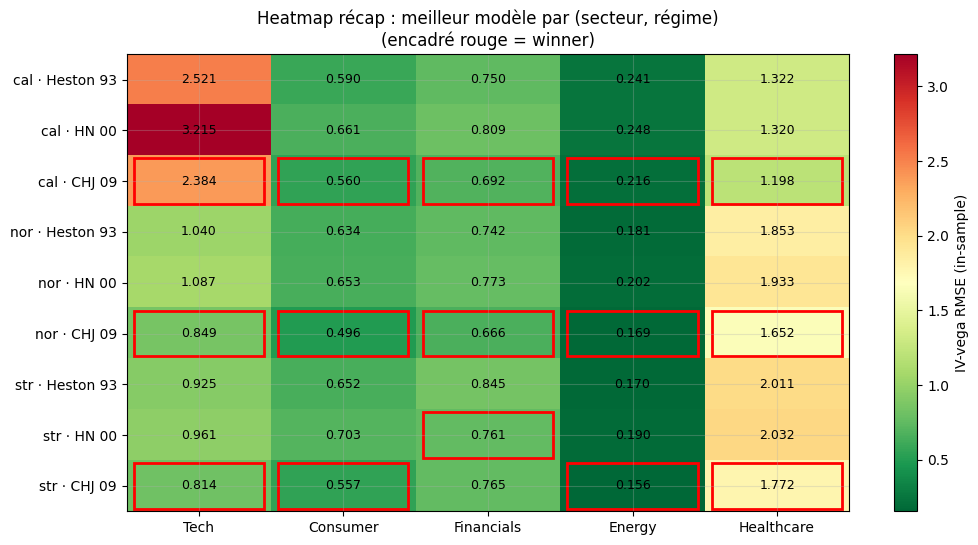

In [12]:
# Pivot : (régime × model) en lignes, secteurs en colonnes
sectors = sectors_present(metrics, SECTOR_MAP)
pivot = (
    metrics.groupby(['regime', 'model', 'sector'])['in_sample_iv_vega_rmse']
    .mean()
    .unstack('sector')
)
# Réordonner régimes et modèles
ordered_idx = [(r, m) for r in REGIME_ORDER for m in MODELS]
pivot = pivot.reindex(ordered_idx)
pivot = pivot[sectors]  # colonnes dans l'ordre des secteurs déclarés

fig, ax = plt.subplots(figsize=(1.5 * len(sectors) + 3, 0.45 * len(pivot) + 1.5))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')

# Annoter les valeurs
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                    fontsize=9, color='black')

# Encadrer le meilleur modèle par (sector, regime)
for s_idx, sec in enumerate(sectors):
    for r in REGIME_ORDER:
        block = pivot.loc[r, sec]
        if block.isna().all(): continue
        best_model = block.idxmin()
        best_row = ordered_idx.index((r, best_model))
        from matplotlib.patches import Rectangle
        ax.add_patch(Rectangle((s_idx - 0.45, best_row - 0.45), 0.9, 0.9,
                                fill=False, edgecolor='red', linewidth=2))

ax.set_xticks(range(len(sectors)))
ax.set_xticklabels(sectors)
ax.set_yticks(range(len(ordered_idx)))
ax.set_yticklabels([f'{r[:3]} · {MODEL_NAMES[m]}' for r, m in ordered_idx])
plt.colorbar(im, ax=ax, label='IV-vega RMSE (in-sample)')
ax.set_title('Heatmap récap : meilleur modèle par (secteur, régime)\n(encadré rouge = winner)')
plt.tight_layout()
plt.savefig('../results/figures/05_heatmap_synthesis.png', dpi=120, bbox_inches='tight')
plt.show()